# Phase 3: Stage A — Selection Model

Fits two complementary models predicting which sentences parents highlight:
1. Hierarchical Bayesian logistic regression (bambi) — estimates uncertainty, random effects
2. Penalized logistic regression (elastic net) — identifies stable predictors

Side-by-side comparison displayed in-notebook.

In [7]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'bambi', 'arviz', 'pymc', 'scikit-learn', 'matplotlib'], check=False)
print('Dependencies ready.')

Dependencies ready.


In [8]:
import os, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

SEED = 20260506
np.random.seed(SEED)

_nb_dir = os.path.abspath('.')
TRACES_DIR = os.path.join(_nb_dir, 'traces')

with open(os.path.join(TRACES_DIR, 'X_stage_a.pkl'), 'rb') as f:
    X_stage_a = pickle.load(f)
with open(os.path.join(TRACES_DIR, 'panel_meta.pkl'), 'rb') as f:
    panel_meta = pickle.load(f)

print(f'X_stage_a: {X_stage_a.shape}')
print(f'panel_meta: {panel_meta.shape}')
print(f'Positive rate: {panel_meta["y"].mean():.1%}')

X_stage_a: (1612, 65)
panel_meta: (1612, 31)
Positive rate: 10.4%


## 3.1  Hierarchical Bayesian logistic regression

In [9]:
import bambi as bmb

# Build model DataFrame: join features with grouping IDs and outcome
model_df_a = X_stage_a.copy()
model_df_a['y'] = panel_meta['y'].values
model_df_a['parent_id'] = panel_meta['parent_id'].values
model_df_a['scenario_id'] = panel_meta['scenario_id'].values

# Drop near-zero-variance columns (can cause sampling issues)
var_thr = 1e-6
low_var_cols = [c for c in X_stage_a.columns if model_df_a[c].var() < var_thr]
if low_var_cols:
    print(f'Dropping {len(low_var_cols)} near-zero-variance columns: {low_var_cols[:5]}...')
    model_df_a = model_df_a.drop(columns=low_var_cols)

feature_cols_a = [c for c in model_df_a.columns
                  if c not in ('y', 'parent_id', 'scenario_id')]
formula_a = 'y ~ ' + ' + '.join(feature_cols_a) + ' + (1|parent_id) + (1|scenario_id)'
print(f'Formula: {formula_a[:120]}...')
print(f'Fixed effects: {len(feature_cols_a)}')

Formula: y ~ domain_Academic_Domain + domain_Casual_Knowledge_Domain + domain_Relationship_Domain + age_band_13_15 + age_band_16_...
Fixed effects: 65


In [10]:
model_a = bmb.Model(formula_a, data=model_df_a, family='bernoulli')

try:
    trace_a = model_a.fit(
        draws=2000, tune=1000, chains=4,
        target_accept=0.95,
        random_seed=SEED,
        progressbar=True
    )
    n_divergences = int(trace_a.sample_stats['diverging'].sum())
    print(f'Sampling done. Divergences: {n_divergences}')

    if n_divergences > 0:
        print(f'Divergences detected ({n_divergences}). Retrying with target_accept=0.99...')
        trace_a = model_a.fit(
            draws=2000, tune=1000, chains=4,
            target_accept=0.99,
            random_seed=SEED,
            progressbar=True
        )
        n_divergences = int(trace_a.sample_stats['diverging'].sum())
        if n_divergences > 0:
            print(f'WARNING: Still {n_divergences} divergences after retry. Proceeding with caveats.')

    # Save trace
    trace_path = os.path.join(TRACES_DIR, 'stage_a_hier.nc')
    trace_a.to_netcdf(trace_path)
    print(f'Trace saved: {trace_path}')

except Exception as e:
    print(f'ERROR during sampling: {e}')
    trace_a = None

Modeling the probability that y==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, domain_Academic_Domain, domain_Casual_Knowledge_Domain, domain_Relationship_Domain, age_band_13_15, age_band_16_18, age_band_6_8, age_band_9_12, gender_identity_boy, gender_identity_girl, gender_identity_nonbinary, sensitivity_level_available, sensitivity_level_intimate, sensitivity_level_sensitive, sensitivity_level_unknown, relationship_frame_companion, relationship_frame_tool, relationship_frame_unknown, space_type_private_space, space_type_shared_family_space, space_type_unknown, breakdown_expected, sub_Behavioral_Norms, sub_Common_Sense, sub_Finance, sub_HW, sub_Health, sub_Privacy, sub_Self, sub_subdomain_other, trait_x_Agreeableness_high, trait_x_Agreeableness_low, trait_x_Conscientiousness_high, trait_x_Conscientiousness_low, trait_x_Extraversion_high, trait_x_Extraversion_low, trait_x_Neuroticism_high, trait_x_Openness_high, trait_x_Openn

Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 67 seconds.


Sampling done. Divergences: 0
Trace saved: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/stat_analysis/pilot_prediction/traces/stage_a_hier.nc


R-hat max: 1.0000  (target < 1.01)
ESS min:   2273    (target > 400)


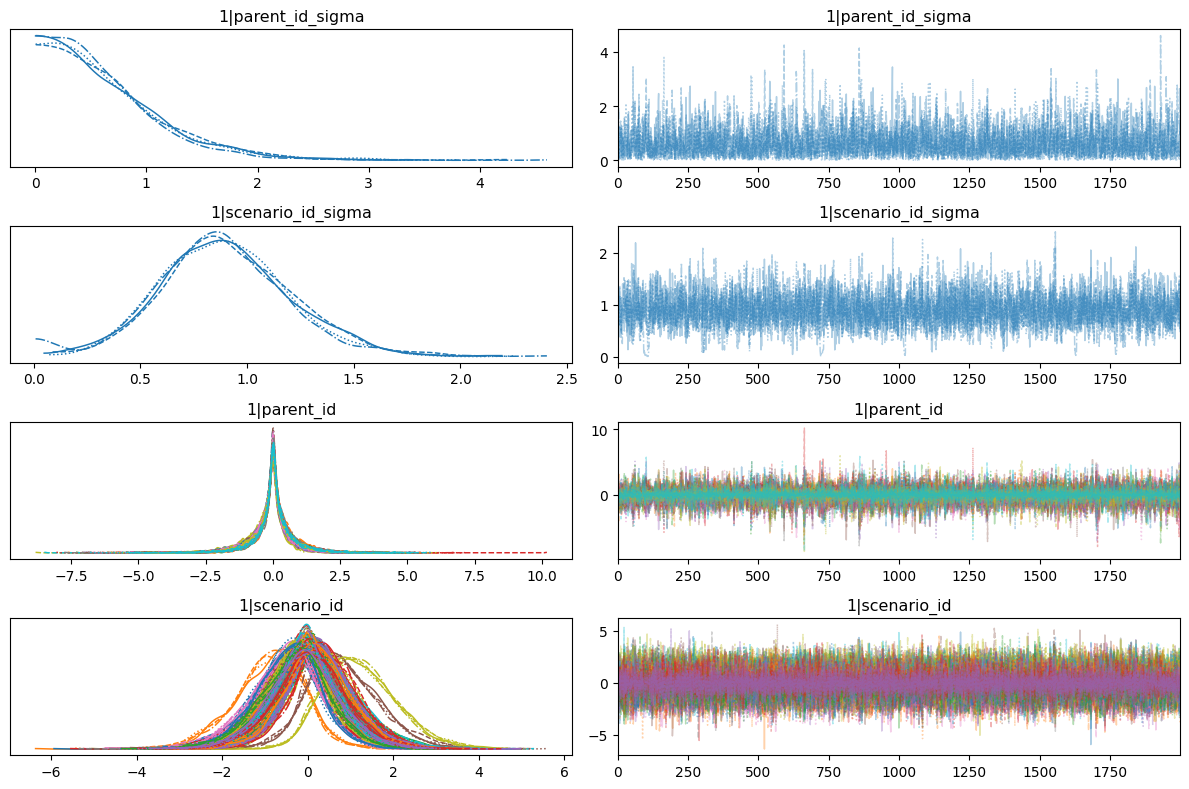

In [11]:
if trace_a is not None:
    # ── Diagnostics ────────────────────────────────────────────────────────
    summary_a = az.summary(trace_a, var_names=[v for v in trace_a.posterior.data_vars
                                                if not v.endswith('_offset')])
    rhat_max = summary_a['r_hat'].max()
    ess_min  = summary_a['ess_bulk'].min()
    print(f'R-hat max: {rhat_max:.4f}  (target < 1.01)')
    print(f'ESS min:   {ess_min:.0f}    (target > 400)')
    if rhat_max >= 1.01:
        print('WARNING: Some R-hat values >= 1.01. Interpret results with caution.')

    # Trace plot for random-effect SDs
    re_vars = [v for v in trace_a.posterior.data_vars if 'sigma' in v.lower() or '1|' in v]
    if re_vars:
        az.plot_trace(trace_a, var_names=re_vars[:4], compact=True)
        plt.tight_layout()
        plt.show()

Top fixed effects by |posterior mean|:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.642,4.932,-12.077,6.761,0.070,0.050,4911.0,5066.0,1.0
relationship_frame_unknown,-1.677,2.823,-7.099,3.494,0.027,0.031,10869.0,6162.0,1.0
sensitivity_level_unknown,-1.640,2.774,-6.810,3.677,0.025,0.032,12192.0,6230.0,1.0
space_type_unknown,-1.623,2.832,-6.936,3.806,0.028,0.032,10166.0,5705.0,1.0
sub_Health,1.586,1.881,-1.987,5.062,0.026,0.020,5276.0,5761.0,1.0
sub_Behavioral_Norms,1.462,1.997,-2.331,5.185,0.032,0.022,3966.0,4952.0,1.0
1|scenario_id[scenario_93355aab-6a8f-4568-93c8-a053bc7640a3],1.222,0.854,-0.244,2.879,0.011,0.009,6041.0,6116.0,1.0
breakdown_expected,-1.191,0.887,-2.824,0.468,0.012,0.010,5847.0,5399.0,1.0
sub_Privacy,1.082,1.641,-1.994,4.105,0.028,0.018,3539.0,4773.0,1.0
eth_white,-1.002,1.434,-3.615,1.773,0.020,0.015,5237.0,5749.0,1.0


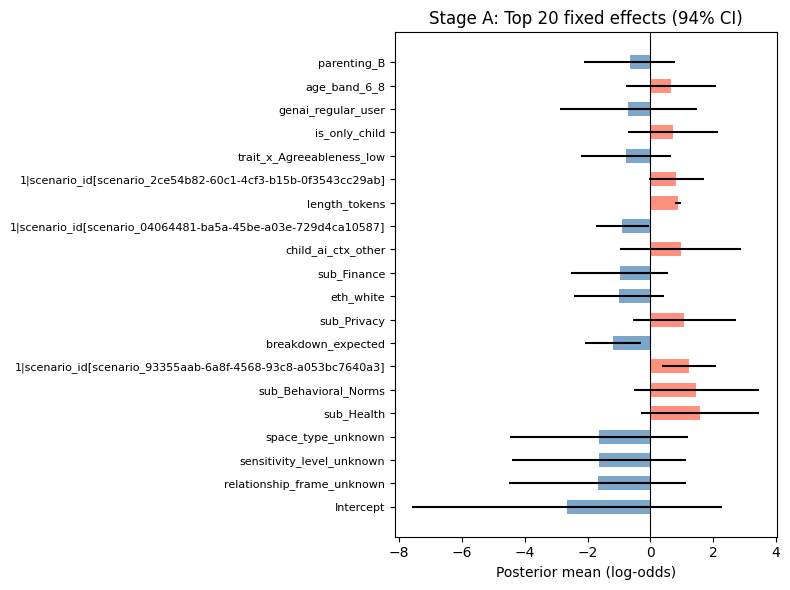

In [12]:
if trace_a is not None:
    # ── Posterior summary for fixed effects ────────────────────────────────
    # az.summary already returns 'mean', 'sd', and HDI columns — do not pass
    # stat_funcs or it will create duplicate column names and break sort_values.
    fixed_vars = [v for v in trace_a.posterior.data_vars
                  if not v.endswith('_offset') and 'sigma' not in v.lower()
                  and 'chol' not in v.lower()]
    hier_coefs = az.summary(trace_a, var_names=fixed_vars, hdi_prob=0.94)
    hier_coefs = hier_coefs.sort_values('mean', key=lambda s: s.abs(), ascending=False)
    print('Top fixed effects by |posterior mean|:')
    display(hier_coefs.head(20))

    # Forest plot of top 20 effects
    top20 = hier_coefs.head(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    y_pos = range(len(top20))
    ax.barh(list(y_pos), top20['mean'], xerr=top20['sd'],
            color=['tomato' if m > 0 else 'steelblue' for m in top20['mean']],
            alpha=0.7, height=0.6)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(top20.index, fontsize=8)
    ax.set_xlabel('Posterior mean (log-odds)')
    ax.set_title('Stage A: Top 20 fixed effects (94% CI)')
    plt.tight_layout()
    plt.show()

## 3.2  Penalized logistic regression (elastic net)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp

# Include parent_id and scenario_id as one-hot fixed effects
enc_parent   = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
enc_scenario = OneHotEncoder(sparse_output=True, handle_unknown='ignore')

y_a = panel_meta['y'].values
X_cont = X_stage_a.fillna(0).values

parent_ohe   = enc_parent.fit_transform(panel_meta[['parent_id']])
scenario_ohe = enc_scenario.fit_transform(panel_meta[['scenario_id']])

X_enet = sp.hstack([sp.csr_matrix(X_cont), parent_ohe, scenario_ohe]).toarray()
print(f'Elastic-net feature matrix: {X_enet.shape}')

Elastic-net feature matrix: (1612, 130)


In [14]:
from sklearn.metrics import average_precision_score
from sklearn.model_selection import GroupKFold

l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
parent_groups = panel_meta['parent_id'].values
gkf = GroupKFold(n_splits=5)

best_score, best_l1r, best_C = -1, None, None
cv_results = []

for l1r in l1_ratios:
    for C in [0.01, 0.1, 1.0, 10.0]:
        scores = []
        for train_idx, val_idx in gkf.split(X_enet, y_a, groups=parent_groups):
            clf = LogisticRegression(
                penalty='elasticnet', solver='saga',
                l1_ratio=l1r, C=C,
                max_iter=500, random_state=SEED
            )
            clf.fit(X_enet[train_idx], y_a[train_idx])
            prob = clf.predict_proba(X_enet[val_idx])[:, 1]
            scores.append(average_precision_score(y_a[val_idx], prob))
        mean_score = np.mean(scores)
        cv_results.append({'l1_ratio': l1r, 'C': C, 'pr_auc': mean_score})
        if mean_score > best_score:
            best_score, best_l1r, best_C = mean_score, l1r, C

cv_df = pd.DataFrame(cv_results)
print(f'Best CV PR-AUC: {best_score:.4f}  (l1_ratio={best_l1r}, C={best_C})')
display(cv_df.pivot(index='C', columns='l1_ratio', values='pr_auc').round(4))

Best CV PR-AUC: 0.3261  (l1_ratio=0.5, C=0.01)


l1_ratio,0.1,0.3,0.5,0.7,0.9
C,,,,,
0.01,0.3046,0.3225,0.3261,0.3261,0.3261
0.10,0.3208,0.3260,0.3183,0.3180,0.3147
1.00,0.3048,0.3063,0.3065,0.3125,0.3157
10.00,0.2689,0.2730,0.2740,0.2774,0.2772


In [15]:
# ── Refit on full data at best hyperparameters ────────────────────────────
clf_final = LogisticRegression(
    penalty='elasticnet', solver='saga',
    l1_ratio=best_l1r, C=best_C,
    max_iter=1000, random_state=SEED
)
clf_final.fit(X_enet, y_a)

# Feature names: structured features + parent OHE + scenario OHE
enet_feature_names = (
    list(X_stage_a.columns)
    + [f'parent_{v}' for v in enc_parent.get_feature_names_out(['parent_id'])]
    + [f'scenario_{v}' for v in enc_scenario.get_feature_names_out(['scenario_id'])]
)

enet_coefs = pd.Series(clf_final.coef_[0], index=enet_feature_names)
# Show only structured feature coefs (exclude OHE group IDs)
enet_structured = enet_coefs[list(X_stage_a.columns)]
nonzero = enet_structured[enet_structured.abs() > 0].sort_values(key=abs, ascending=False)

print(f'Non-zero structured feature coefficients: {len(nonzero)} / {len(X_stage_a.columns)}')
display(nonzero.head(20).to_frame('enet_coef'))

Non-zero structured feature coefficients: 1 / 65


,enet_coef
length_tokens,0.378144


## 3.3  Hierarchical vs. elastic-net comparison

In [16]:
if trace_a is not None:
    # Build comparison DataFrame for structured features
    hier_means = {}
    hier_lo = {}
    hier_hi = {}
    for feat in X_stage_a.columns:
        if feat in hier_coefs.index:
            hier_means[feat] = hier_coefs.loc[feat, 'mean']
            hier_lo[feat]    = hier_coefs.loc[feat, 'hdi_3%']
            hier_hi[feat]    = hier_coefs.loc[feat, 'hdi_97%']

    comparison = pd.DataFrame({
        'hier_mean':  pd.Series(hier_means),
        'hier_ci_lo': pd.Series(hier_lo),
        'hier_ci_hi': pd.Series(hier_hi),
        'enet_coef':  enet_structured,
    }).dropna(subset=['hier_mean'])

    comparison['CI_excludes_0'] = (
        (comparison['hier_ci_lo'] > 0) | (comparison['hier_ci_hi'] < 0)
    ).astype(bool)
    comparison['enet_selected'] = (comparison['enet_coef'].abs() > 0)
    comparison['sign_agrees'] = np.sign(comparison['hier_mean']) == np.sign(comparison['enet_coef'])
    comparison['agreement_flag'] = (
        comparison['CI_excludes_0'] &
        comparison['enet_selected'] &
        comparison['sign_agrees']
    )

    print(f'Features with full agreement (candidate Wave 2 hypotheses): {comparison["agreement_flag"].sum()}')
    display(comparison.sort_values('hier_mean', key=abs, ascending=False).head(30).round(4))

    with open(os.path.join(TRACES_DIR, 'stage_a_comparison.pkl'), 'wb') as f:
        pickle.dump(comparison, f)
else:
    print('Hierarchical trace not available — comparison skipped.')
    comparison = None

# Save elastic-net results
with open(os.path.join(TRACES_DIR, 'enet_coefs_a.pkl'), 'wb') as f:
    pickle.dump({'coefs': enet_structured, 'clf': clf_final,
                 'enc_parent': enc_parent, 'enc_scenario': enc_scenario,
                 'best_l1r': best_l1r, 'best_C': best_C}, f)

print('Stage A results saved.')

Features with full agreement (candidate Wave 2 hypotheses): 1


,hier_mean,hier_ci_lo,hier_ci_hi,enet_coef,CI_excludes_0,enet_selected,sign_agrees,agreement_flag
relationship_frame_unknown,-1.677,-7.099,3.494,0.0000,False,False,False,False
sensitivity_level_unknown,-1.640,-6.810,3.677,0.0000,False,False,False,False
space_type_unknown,-1.623,-6.936,3.806,0.0000,False,False,False,False
sub_Health,1.586,-1.987,5.062,0.0000,False,False,False,False
sub_Behavioral_Norms,1.462,-2.331,5.185,0.0000,False,False,False,False
breakdown_expected,-1.191,-2.824,0.468,0.0000,False,False,False,False
sub_Privacy,1.082,-1.994,4.105,0.0000,False,False,False,False
eth_white,-1.002,-3.615,1.773,0.0000,False,False,False,False
sub_Finance,-0.974,-4.007,1.789,0.0000,False,False,False,False
child_ai_ctx_other,0.963,-2.678,4.437,0.0000,False,False,False,False


Stage A results saved.


## 3.4  Interpretable baselines: Simple LR and Shallow Decision Tree

Two additional models using the same `X_enet` feature matrix and GroupKFold(5) by `parent_id`
for a fair apples-to-apples comparison with the elastic net.

Metrics per fold and pooled:
- **PR-AUC** (primary) — handles class imbalance; threshold-free
- **ROC-AUC** — overall discrimination
- **Accuracy** — at default 0.5 threshold (inflated by majority class; use with caution)
- **F1-weighted** and **F1-macro**
- **Brier score** — calibration quality (lower = better, baseline ≈ p*(1-p))

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    accuracy_score, f1_score, brier_score_loss
)
from sklearn.model_selection import GroupKFold

# Majority-class baseline positive rate
pos_rate = y_a.mean()
brier_baseline = pos_rate * (1 - pos_rate)

models_to_eval = {
    'Elastic Net (best)': LogisticRegression(
        penalty='elasticnet', solver='saga',
        l1_ratio=best_l1r, C=best_C,
        max_iter=500, random_state=SEED
    ),
    'Simple LR (no penalty)': LogisticRegression(
        penalty=None, solver='lbfgs',
        max_iter=1000, random_state=SEED
    ),
    'Decision Tree (depth=3)': DecisionTreeClassifier(
        max_depth=3, min_samples_leaf=10, random_state=SEED
    ),
    'Decision Tree (depth=5)': DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=5, random_state=SEED
    ),
}

gkf = GroupKFold(n_splits=5)
fold_records = []

for name, model in models_to_eval.items():
    for fold, (train_idx, val_idx) in enumerate(
            gkf.split(X_enet, y_a, groups=parent_groups)):
        try:
            m = model.__class__(**model.get_params())
            m.fit(X_enet[train_idx], y_a[train_idx])
            prob = m.predict_proba(X_enet[val_idx])[:, 1]
            pred = m.predict(X_enet[val_idx])
            y_val = y_a[val_idx]
            fold_records.append({
                'model': name,
                'fold': fold,
                'pr_auc':      average_precision_score(y_val, prob),
                'roc_auc':     roc_auc_score(y_val, prob),
                'accuracy':    accuracy_score(y_val, pred),
                'f1_weighted': f1_score(y_val, pred, average='weighted', zero_division=0),
                'f1_macro':    f1_score(y_val, pred, average='macro', zero_division=0),
                'brier':       brier_score_loss(y_val, prob),
            })
        except Exception as e:
            print(f'  {name} fold {fold} failed: {e}')

fold_df = pd.DataFrame(fold_records)
print(f'CV complete. {len(fold_df)} fold-model results.')

CV complete. 20 fold-model results.


=== Stage A: Model comparison (GroupKFold-5, grouped by parent) ===


,PR-AUC,ROC-AUC,Accuracy,F1-weighted,F1-macro,Brier
Elastic Net (best),0.326 ± 0.061,0.771 ± 0.039,0.896 ± 0.031,0.851 ± 0.040,0.492 ± 0.017,0.088 ± 0.025
Simple LR (no penalty),0.240 ± 0.038,0.672 ± 0.058,0.835 ± 0.064,0.835 ± 0.050,0.558 ± 0.028,0.127 ± 0.043
Decision Tree (depth=3),0.212 ± 0.068,0.700 ± 0.072,0.891 ± 0.029,0.855 ± 0.037,0.525 ± 0.050,0.089 ± 0.023
Decision Tree (depth=5),0.217 ± 0.035,0.734 ± 0.030,0.885 ± 0.028,0.851 ± 0.044,0.521 ± 0.034,0.092 ± 0.024
--- Baseline ---,0.104 (rate),0.500 (chance),0.896 (majority),0.896 (majority),—,0.093 (rate)


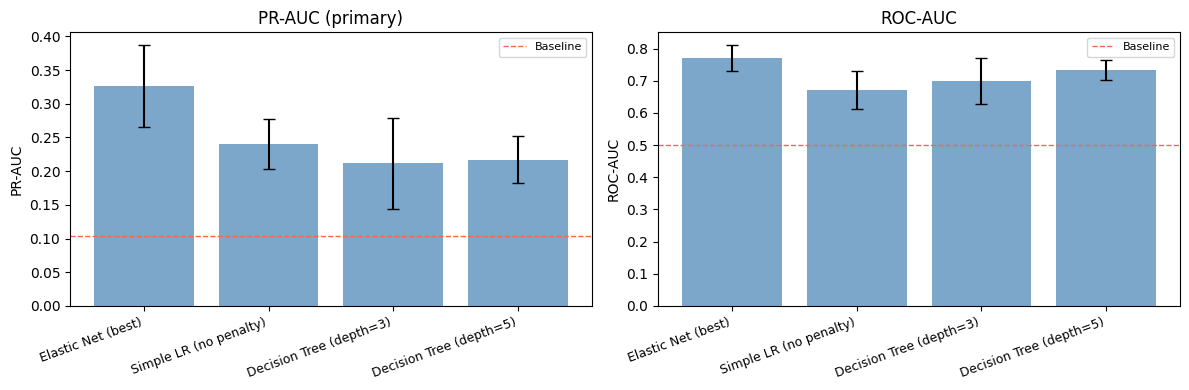

In [19]:
# ── Summary metrics table ─────────────────────────────────────────────────
metrics = ['pr_auc', 'roc_auc', 'accuracy', 'f1_weighted', 'f1_macro', 'brier']

summary_rows = []
for name, grp in fold_df.groupby('model', sort=False):
    row = {'model': name}
    for m in metrics:
        row[f'{m}_mean'] = grp[m].mean()
        row[f'{m}_std']  = grp[m].std()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('model')

# Formatted display: mean ± std per metric
display_rows = {}
for name in summary_df.index:
    display_rows[name] = {
        m: f"{summary_df.loc[name, f'{m}_mean']:.3f} ± {summary_df.loc[name, f'{m}_std']:.3f}"
        for m in metrics
    }

# Baselines for reference
baselines = {
    'pr_auc':      f'{pos_rate:.3f} (rate)',
    'roc_auc':     '0.500 (chance)',
    'accuracy':    f'{1 - pos_rate:.3f} (majority)',
    'f1_weighted': f'{2*(1-pos_rate)**2 / (2*(1-pos_rate)):.3f} (majority)',
    'f1_macro':    '—',
    'brier':       f'{brier_baseline:.3f} (rate)',
}
display_rows['--- Baseline ---'] = baselines

metrics_table = pd.DataFrame(display_rows).T
metrics_table.columns = ['PR-AUC', 'ROC-AUC', 'Accuracy', 'F1-weighted', 'F1-macro', 'Brier']
print('=== Stage A: Model comparison (GroupKFold-5, grouped by parent) ===')
display(metrics_table)

# Bar chart — PR-AUC and ROC-AUC side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_names = list(summary_df.index)
x = range(len(model_names))

for ax, metric, title, baseline_val in [
    (axes[0], 'pr_auc',  'PR-AUC (primary)',  pos_rate),
    (axes[1], 'roc_auc', 'ROC-AUC',           0.5),
]:
    means = [summary_df.loc[n, f'{metric}_mean'] for n in model_names]
    stds  = [summary_df.loc[n, f'{metric}_std']  for n in model_names]
    ax.bar(x, means, yerr=stds, capsize=4, color='steelblue', alpha=0.7)
    ax.axhline(baseline_val, color='tomato', linestyle='--', linewidth=1, label='Baseline')
    ax.set_xticks(list(x))
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel(metric.upper().replace('_', '-'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

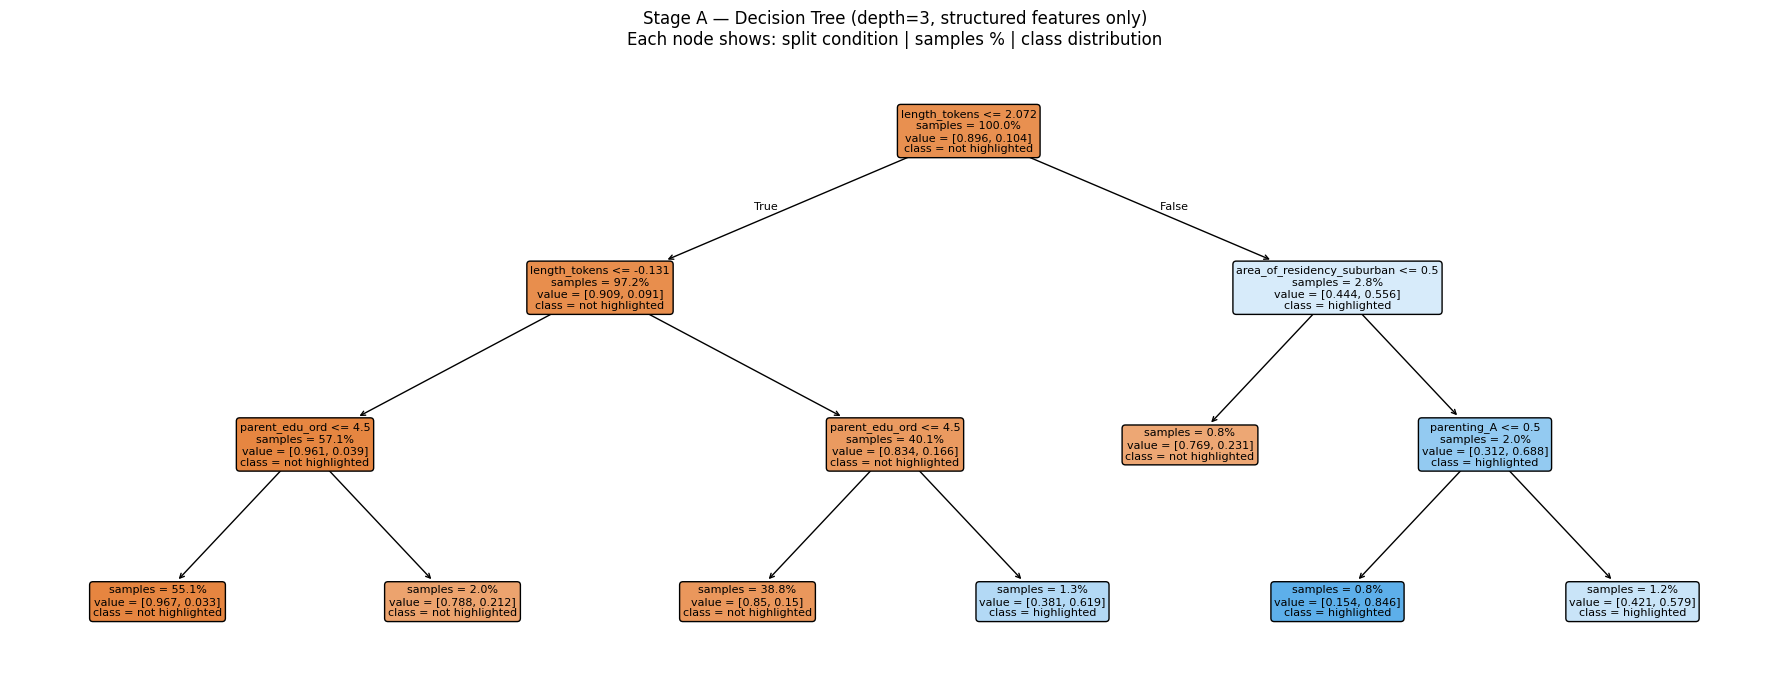


Features used by depth-3 tree (4 non-zero):


,importance
length_tokens,0.6607
parent_edu_ord,0.2337
area_of_residency_suburban,0.0821
parenting_A,0.0235



Cross-check vs Bayesian model (CI excludes 0):
  length_tokens: DT imp=0.6607, Bayes mean=0.883 [0.700, 1.067]  → CI excl. 0
  parent_edu_ord: DT imp=0.2337, Bayes mean=0.057 [-0.590, 0.706]  → CI incl. 0
  area_of_residency_suburban: DT imp=0.0821, Bayes mean=0.233 [-2.450, 3.078]  → CI incl. 0
  parenting_A: DT imp=0.0235, Bayes mean=-0.456 [-2.757, 1.744]  → CI incl. 0


In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Fit depth-3 DT on structured features only (interpretable splits) ─────
# Use X_stage_a (no parent/scenario OHE) so tree nodes refer to content features.
X_struct = X_stage_a.fillna(0).values
struct_feature_names = list(X_stage_a.columns)

dt3 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=SEED)
dt3.fit(X_struct, y_a)

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt3,
    feature_names=struct_feature_names,
    class_names=['not highlighted', 'highlighted'],
    filled=True, rounded=True, fontsize=8,
    impurity=False, proportion=True, ax=ax
)
ax.set_title('Stage A — Decision Tree (depth=3, structured features only)\n'
             'Each node shows: split condition | samples % | class distribution')
plt.tight_layout()
plt.show()

# ── Feature importances (depth-3 tree) ────────────────────────────────────
imp = pd.Series(dt3.feature_importances_, index=struct_feature_names)
imp_nonzero = imp[imp > 0].sort_values(ascending=False)
print(f'\nFeatures used by depth-3 tree ({len(imp_nonzero)} non-zero):')
display(imp_nonzero.to_frame('importance').round(4))

# Cross-check: which of these also have Bayesian CI excluding 0?
if trace_a is not None:
    print('\nCross-check vs Bayesian model (CI excludes 0):')
    for feat in imp_nonzero.index:
        if feat in hier_coefs.index:
            lo = hier_coefs.loc[feat, 'hdi_3%']
            hi = hier_coefs.loc[feat, 'hdi_97%']
            ci_flag = 'CI excl. 0' if (lo > 0 or hi < 0) else 'CI incl. 0'
            print(f'  {feat}: DT imp={imp[feat]:.4f}, Bayes mean={hier_coefs.loc[feat,"mean"]:.3f} [{lo:.3f}, {hi:.3f}]  → {ci_flag}')